**Imbalanced** - When one class has very high percentage compared to other class.
- 90% - class 0
- 10% - class1

**Solutions to imbalance**

**1)Undersampling (down sampling)** - We balance both classes by removing the class which has huge percentage equal to other class, it can cause loss of data.

**2)Oversampling (up sampling)** - We repeat the minority class data and try to balance both classes.

**3)SMOTE** - Also called as Synthetic Minority OversamplingTechnique. In this method we generate data points artificially matching the data given avoiding problem of pattern mismatch. Like datapoints will always be together making it effective.

# Data Interpolation

Data Interpolation is the process of estimating unknown values fromthe known values.
- Linear interpolation
- Cubic interpolation
- Polynominal interpolation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

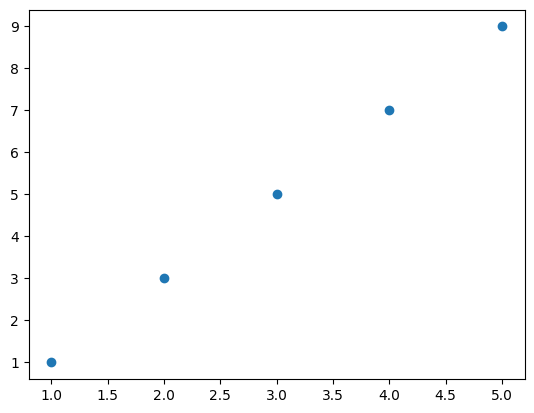

In [2]:
x=np.array([1,2,3,4,5])
y=np.array([1,3,5,7,9])
plt.scatter(x,y)

In [3]:
# linear interpolation
x_new=np.linspace(1,5,10)
y_interp=np.interp(x_new,x,y)

In [5]:
y_interp

array([1.        , 1.88888889, 2.77777778, 3.66666667, 4.55555556,
       5.44444444, 6.33333333, 7.22222222, 8.11111111, 9.        ])

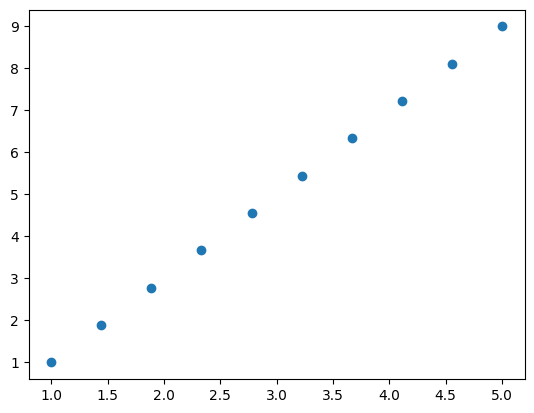

In [6]:
plt.scatter(x_new, y_interp)

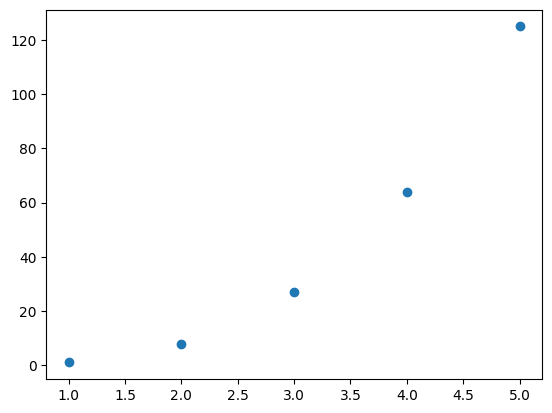

In [7]:
# cubic interpolation
x=np.array([1,2,3,4,5])
y=np.array([1,8,27,64,125])
plt.scatter(x,y)

In [8]:
from scipy.interpolate import interp1d
f= interp1d(x,y,kind='cubic')

In [9]:
f

In [10]:
x_new=np.linspace(1,5,10)
y_interp=f(x_new)

In [11]:
y_interp

array([  1.        ,   3.01371742,   6.739369  ,  12.7037037 ,
        21.43347051,  33.45541838,  49.2962963 ,  69.48285322,
        94.54183813, 125.        ])

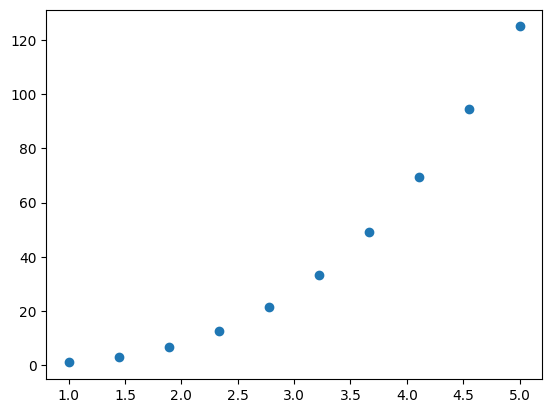

In [12]:
plt.scatter(x_new,y_interp)

In [13]:
# polynominal interpolation
x=np.array([1,2,3,4,5])
y=np.array([1,4,9,1,25])
#interpolating using polynominal interpolation
p=np.polyfit(x,y,2)

In [20]:
x_new=np.linspace(1,5,10)
y_interp=np.polyval(p, x_new)

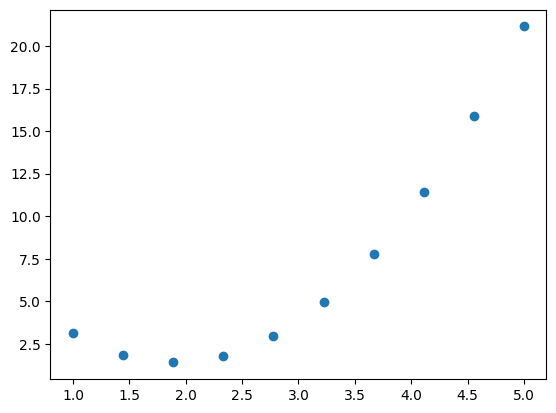

In [22]:
plt.scatter(x_new, y_interp)

# Outliers and its Treatment

Outliers are extreme values

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [25]:
salary=[11,40,45,68,65,68,78,90,57,74,91,93,88,68,57,48,99,101,68,57,48,99,101,77,110,140]

In [26]:
salary

[11,
 40,
 45,
 68,
 65,
 68,
 78,
 90,
 57,
 74,
 91,
 93,
 88,
 68,
 57,
 48,
 99,
 101,
 68,
 57,
 48,
 99,
 101,
 77,
 110,
 140]

In [27]:
np.quantile(salary,[0,0.25,0.5,0.75,1])

array([ 11. ,  57. ,  71. ,  92.5, 140. ])

In [28]:
df=pd.DataFrame(salary, columns=['Salary'])

In [29]:
df.describe()

,Salary
count,26.000000
mean,74.653846
std,26.747624
min,11.000000
25%,57.000000
50%,71.000000
75%,92.500000
max,140.000000


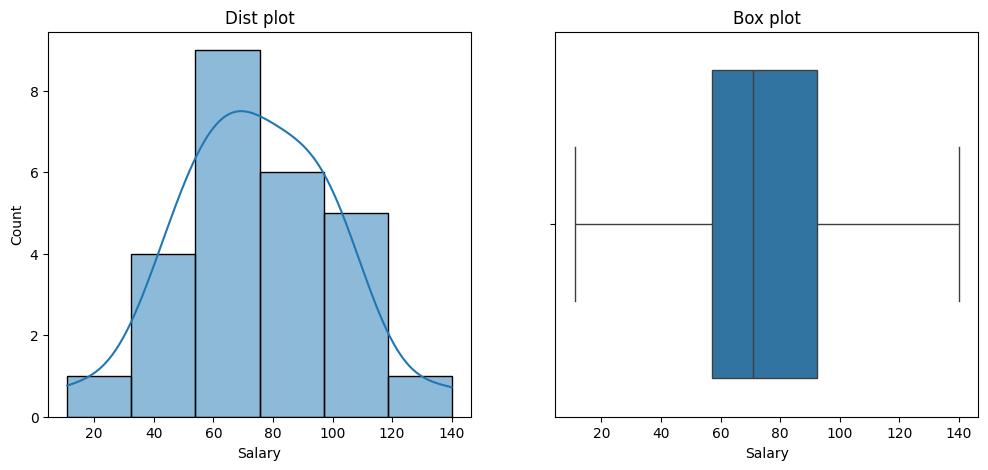

In [30]:
# for checking outliers we now plot displot and boxplot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Salary'], kde=True)
plt.title("Dist plot")

plt.subplot(1,2,2)
sns.boxplot(data=df, x ='Salary')
plt.title("Box plot")
plt.show()

In [31]:
# dropping outlier
Q1=df['Salary'].quantile(0.25)
Q3=df['Salary'].quantile(0.75)
IQR=Q3-Q1
lower_fence=Q1-1.5*IQR
upper_fence=Q3+1.5*IQR

In [32]:
df_filtered=df[(df.Salary>= lower_fence)&(df.Salary<=upper_fence)]

In [33]:
df.shape

(26, 1)

In [36]:
df_filtered.shape

(26, 1)

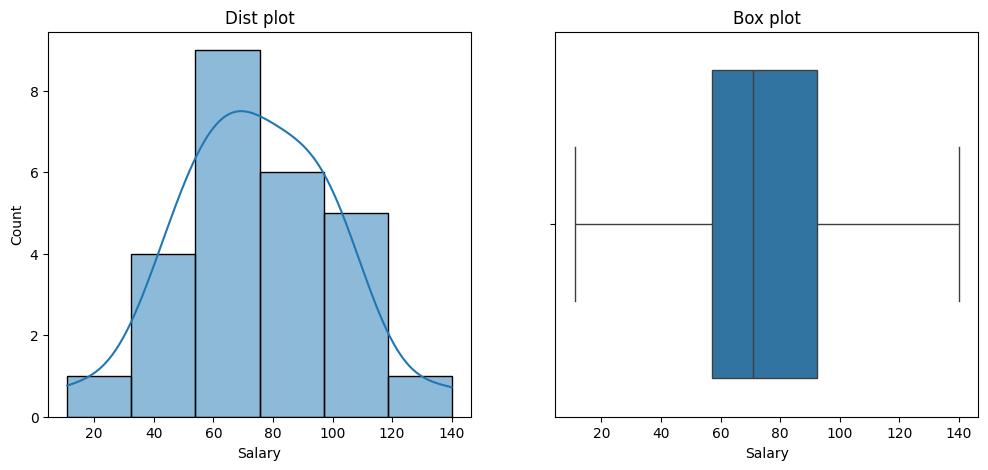

In [37]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_filtered['Salary'], kde=True)
plt.title("Dist plot")

plt.subplot(1,2,2)
sns.boxplot(data=df_filtered, x ='Salary')
plt.title("Box plot")
plt.show()